## Time series analysis of lateral velocity:
This notebook analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [2]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import welch
import csv
import gc
import parameters as par

In [2]:
# Defining functions:
def U_read(taxon, file): # Reads in velocity data from paraview, converts to cm/s and returns as array.
    dir = '../' + taxon +'/velocity/v0.1/postProcessing/'
    with open(dir + file) as f:
        #row_count = sum(1 for row in f)
        U = []
        u = []
        v = []
        w = []
        minv = []
        q1v = []
        q3v = []
        maxv = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            U.append(float(row['avg(U (Magnitude))']))  # Access by column header instead of column number
            u.append(float(row['avg(U (0))']))  
            v.append(float(row['avg(U (1))']))
            w.append(float(row['avg(U (2))']))
            minv.append(float(row['min(U (1))']))  
            maxv.append(float(row['max(U (1))']))
            q1v.append(float(row['q1(U (1))']))  
            q3v.append(float(row['q3(U (1))']))

            
        U = np.array(U)
        u = np.array(u)
        v = np.array(v)
        w = np.array(w)
        minv = np.array(minv)
        maxv = np.array(maxv)
        q1v = np.array(q1v)
        q3v = np.array(q3v)
        
        #x = x*100  #convert to cm
        #Umag = np.sqrt((u**2)+(v**2)+(w**2))*1000
        #print(Umag.shape)
        U_final = np.array((U*100,u*100,v*100,w*100,minv*100,q1v*100,q3v*100,maxv*100))#Umag
        
        return U_final

def FFT_read(taxon, file, L):
    # Reads in FFT data from paraview, removes negative frequencies and computes Strouhal number based
    # on characteristic length provided, assuming free stream velocity of 0.1m/s.
    dir = '../' + taxon +'/velocity/v0.1/postProcessing/'
    with open(dir + file) as f:
        freq = []
        Fx = []
        Fy = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            freq.append(float(row['Frequency']))  # Access by column header instead of column number
            Fx.append(float(row['avg(U (1)):0']))  
            Fy.append(float(row['avg(U (1)):1']))  

        freq = np.array(freq)
        Fx = np.array(Fx)
        Fy = np.array(Fy)
        F = np.sqrt(Fx**2 + Fy**2) 
        # removing -ve frequencies
        freq_pos = freq[freq >= 0]
        F_pos = F[:len(freq_pos)]

        # Strouhal number: St = f*L/U
        U = 0.1 # free stream velocity
        strouhal = freq_pos*L/U
        
        FFT_final = np.array((strouhal,F_pos))#Umag
        
        return FFT_final

def plot(taxon1, taxon2, writeInt1, writeInt2, time_series1, time_series2, FFT1, FFT2): # Plots time series and FFT data for two taxa side by side.
    t1 = np.arange(0,40+writeInt1,writeInt1)
    t2 = np.arange(0,40+writeInt2,writeInt2)
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300, gridspec_kw={'width_ratios':[2,1]})
    axs[0].plot(t1, time_series1[2], linewidth=1, color='#1F8741', label=taxon1, alpha=0.4)
    axs[0].plot(t2, time_series2[2], linestyle = '--', linewidth=1, color='#9C0976', label=taxon2, alpha=0.4)
    axs[0].fill_between(t1, time_series1[5], time_series1[6], color='#1F8741', alpha=0.2)
    axs[0].fill_between(t2, time_series2[5], time_series2[6], color='#9C0976', alpha=0.2)
    axs[0].set_ylabel(r'u$_y$ (cm/s)')
    axs[0].set_xlabel(r't (s)')
    axs[0].set_ylim(-4,4)
    axs[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # create custom linestyle legend entries
    solid_handle = Line2D([0], [0], color='#1F8741', linestyle='-', linewidth=1, alpha=0.8)
    dashed_handle = Line2D([0], [0], color='#9C0976', linestyle='--', linewidth=1, alpha=0.8)

    fig.legend(
        [solid_handle, dashed_handle],
        [taxon1, taxon2],
        loc=1,
        bbox_to_anchor=(0.32, 0.3),
    )
    axs[1].plot(FFT1[0], FFT1[1], linewidth=1, color='#1F8741', label=taxon1)
    axs[1].plot(FFT2[0], FFT2[1], linestyle = '--', linewidth=1, color='#9C0976', label=taxon2)
    axs[1].set_xlabel('Strouhal Number')
    axs[1].set_ylabel(r'FFT of u$_y$ (cm/s)')
    axs[1].tick_params(axis='both', which='major', labelsize=8)
    axs[1].set_ylim(0, 0.2)
    fig.tight_layout()

def read_Cl(taxon1, taxon2, writeInt1, writeInt2): # Plots time series and FFT data for two taxa side by side.
    dir1 = '../' + taxon1 +'/velocity/v0.1/postProcessing/forces/0/'
    dir2 = '../' + taxon2 +'/velocity/v0.1/postProcessing/forces/0/'
    #helicocystis_straight/velocity/v0.1/postProcessing/forces/0
    filename1 = dir1 + 'forceCoeffs.dat'
    filename2 = dir2 + 'forceCoeffs.dat'
    # Read the forceCoeffs.dat file and extract Cd values from timestep 50 onwards
    with open(filename1, 'r') as file:
        lines = file.readlines()
        if not lines:
            raise ValueError("The file is empty.")
        #data_lines = lines[29:]  # take data from 30s onwards
        Cl_1_list = []
        for line in lines:
            if line.strip() and not line.startswith('#'):
                parts = line.split()
                if len(parts) > 2:
                    Cl_1_list.append(float(parts[3]))
        Cl_1 =  np.array(Cl_1_list)

    with open(filename2, 'r') as file:
        lines = file.readlines()
        if not lines:
            raise ValueError("The file is empty.")
        #data_lines = lines[29:]  # take data from 30s onwards
        Cl_2_list = []
        for line in lines:
            if line.strip() and not line.startswith('#'):
                parts = line.split()
                if len(parts) > 2:
                    Cl_2_list.append(float(parts[3]))
        Cl_2 =  np.array(Cl_2_list)
        Cl_2 = Cl_2*0.00024/0.0000331 # scaling with correct frontal area

    # FFT of Cl
    n1 = len(Cl_1)
    n2 = len(Cl_2)
    dt1 = writeInt1
    dt2 = writeInt2 
    freq1 = np.fft.rfftfreq(n1, d=dt1)
    freq2 = np.fft.rfftfreq(n2, d=dt2)
    print(freq2)

    FFT_Cl_1 = np.fft.rfft(Cl_1)
    FFT_Cl_2 = np.fft.rfft(Cl_2)
    print(FFT_Cl_2)

    return Cl_1, Cl_2, freq1, freq2, FFT_Cl_1, FFT_Cl_2

def plot_Cl(taxon1, taxon2, writeInt1, writeInt2, Cl_1, Cl_2, freq1, freq2, FFT_Cl_1, FFT_Cl_2): # Plots time series and FFT data for two taxa side by side.
    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300, gridspec_kw={'width_ratios':[2,1]})
    axs[0].plot(np.arange(0, 40+writeInt1, writeInt1), Cl_1, linewidth=1, color='#1F8741', label=taxon1)
    axs[0].plot(np.arange(0, 40+writeInt2, writeInt2), Cl_2, linestyle = '--', linewidth=1, color='#9C0976', label=taxon2)
    axs[0].set_ylabel(r'Cl')
    axs[0].set_xlabel(r't (s)')
    axs[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # create custom linestyle legend entries
    solid_handle = Line2D([0], [0], color='#1F8741', linestyle='-', linewidth=1, alpha=0.8)
    dashed_handle = Line2D([0], [0], color='#9C0976', linestyle='--', linewidth=1, alpha=0.8)   

    fig.legend(
        [solid_handle, dashed_handle],
        [taxon1, taxon2],
        loc=1,
        bbox_to_anchor=(0.32, 0.3),
    )
    axs[1].plot(freq1, FFT_Cl_1, linewidth=1, color='#1F8741', label=taxon1)
    axs[1].plot(freq2, FFT_Cl_2, linestyle = '--', linewidth=1, color='#9C0976', label=taxon2)
    axs[1].set_xlabel('Frequency (Hz)')
    axs[1].set_ylabel(r'FFT of Cl')
    axs[1].tick_params(axis='both', which='major', labelsize=8)
    fig.tight_layout()

### Edrioasteroids

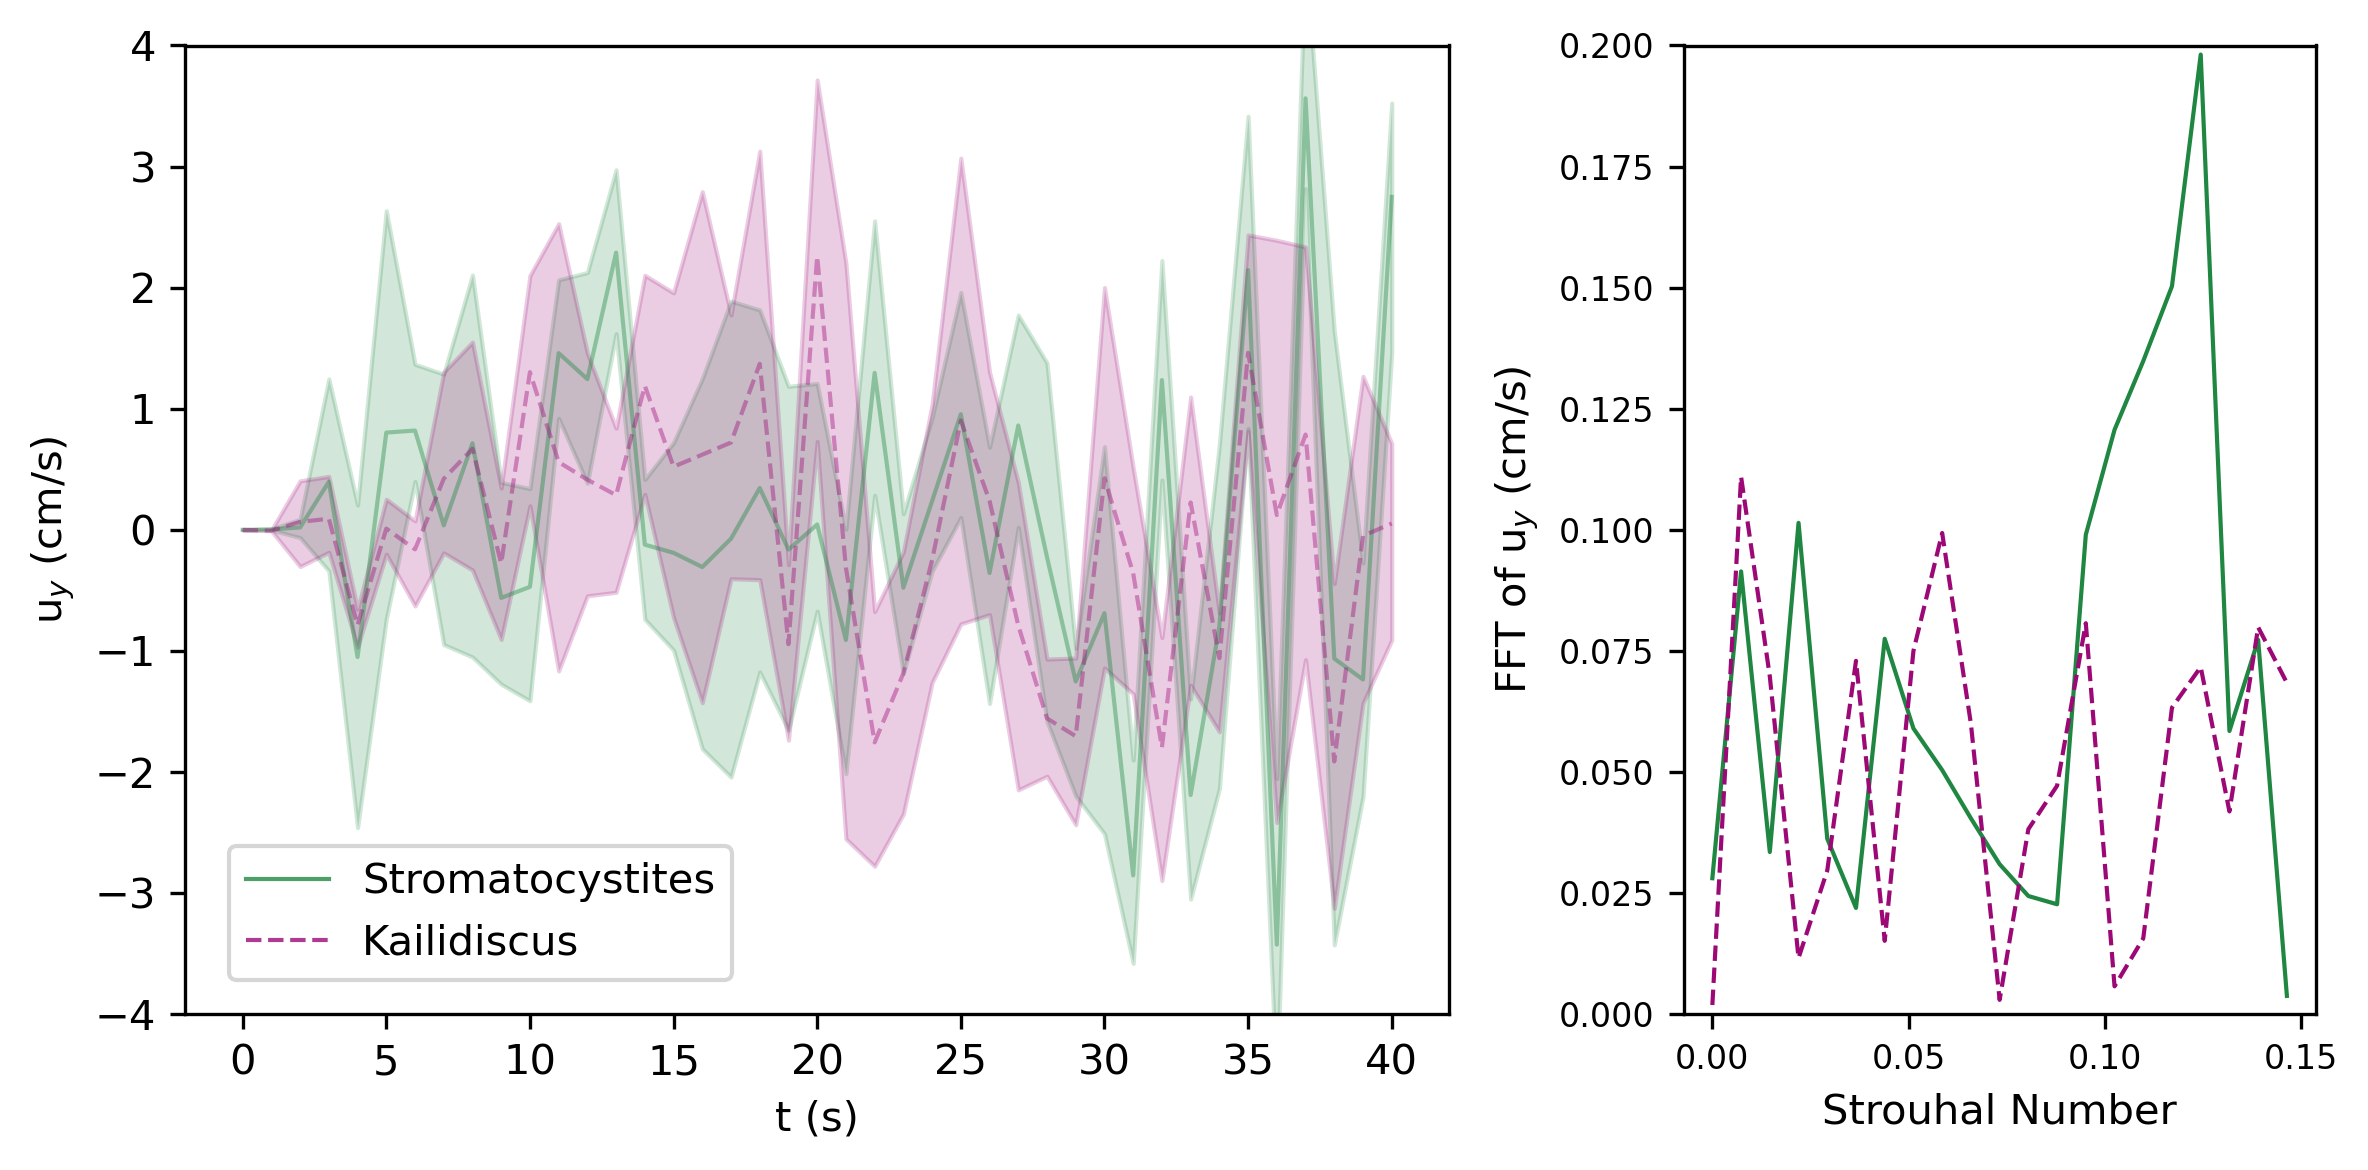

In [11]:
time_series_stromat = U_read('stromatocystites', 'time_series.csv')
time_series_kaili = U_read('kailidiscus', 'time_series.csv')
FFT_stromat = FFT_read('stromatocystites', 'FFT.csv', 0.03)
FFT_kaili = FFT_read('kailidiscus', 'FFT.csv', 0.03)
plot('Stromatocystites', 'Kailidiscus', 1, 1, time_series_stromat, time_series_kaili, FFT_stromat, FFT_kaili)
#plt.savefig('time_series_edrioasteroids.pdf', dpi=300)

Peak occurs at : 0.87890625  Hz


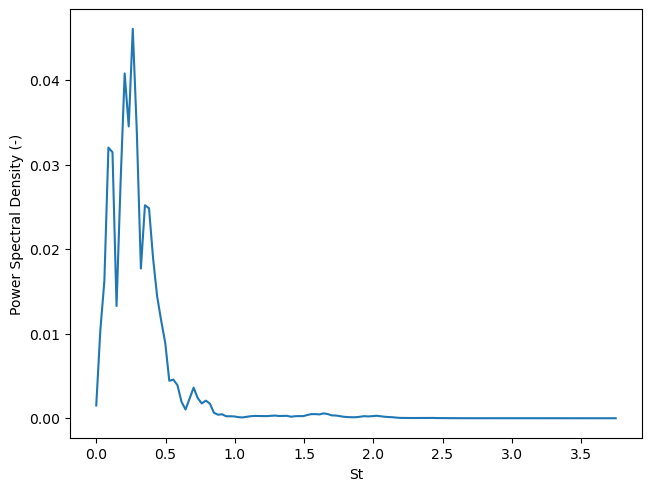

'\ndirect = \'../stromatocystites/video/base_case/postProcessing/\'\nfile = \'probe_0.15_0.06_0.015.csv\'\nwith open(direct + file) as f:\n    v = []\n    reader = csv.DictReader(f, delimiter=\',\')\n    for row in reader:\n        v.append(float(row[\'avg(U (1))\']))\n\n    v = np.array(v)*100\n\nv = np.abs(v[750:])#v[520:])\nt = np.arange(30,60+0.04,0.04)#20.8, 60+0.04, 0.04)\nprint(t.shape)\nfs = 1/0.04\n\nfig, (ax0, ax1) = plt.subplots(1, 2, layout=\'constrained\')\nax0.plot(t, v)\nax0.set_xlabel(\'Time (s)\')\nax0.set_ylabel(r\'$U_y$\'\' (cm s\'r\'$^{-1}$)\')\nax0.set_ylim(0,2)\n#ax1.psd(Cl_1, \n        #pad_to=len(t), \n#        NFFT=1024,#len(t),\n#        Fs=fs,\n#        sides=\'onesided\'\n#        )\nf, pxx = welch(v, fs)\nL = 0.03\nU = 0.1\nst = f*L/U\n# Find the index of the maximum y value\nmax_pxx_index = np.argmax(pxx)\n\n# Retrieve the x value at that index\nmax_f_value = f[max_pxx_index]\n\nprint("Peak occurs at :", max_f_value, " Hz")\n\nax1.plot(st, pxx)\nax1.set_xl

In [3]:
def calc_FFT(taxon, file, L):
    dir = '/home/jmcdermo/projects/nhm/jmcdermo/spirals/' + taxon + '/video/base_case/postProcessing/'
    with open(dir + file) as f:
        v = []
        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            v.append(float(row['avg(U (1))']))

    v = np.array(v)*100
    v = np.abs(v[750:])
    t = np.arange(30,60+0.04,0.04) #final 30 seconds of 60s run
    fs = 1/0.04

    f, pxx = welch(v, fs)
    U = 0.1
    st = f*L/U
    # Find the index of the maximum y value
    max_pxx_index = np.argmax(pxx)

    # Retrieve the x value at that index
    max_f_value = f[max_pxx_index]

    print("Peak occurs at :", max_f_value, " Hz")

    return {'frequency': f, 'strouhal': st, 'psd': pxx}

stromato_FFT = calc_FFT(par.Stromatocystites.name, 'probe_0.15_0.06_0.015.csv', par.Stromatocystites.L)

fig, ax = plt.subplots(1, 1, layout='constrained')
ax.plot(stromato_FFT['strouhal'], stromato_FFT['psd'])
ax.set_xlabel("St")
ax.set_ylabel("Power Spectral Density (-)")

#ax1.set_xlim(0,0.5)
plt.show()

'''
direct = '../stromatocystites/video/base_case/postProcessing/'
file = 'probe_0.15_0.06_0.015.csv'
with open(direct + file) as f:
    v = []
    reader = csv.DictReader(f, delimiter=',')
    for row in reader:
        v.append(float(row['avg(U (1))']))

    v = np.array(v)*100

v = np.abs(v[750:])#v[520:])
t = np.arange(30,60+0.04,0.04)#20.8, 60+0.04, 0.04)
print(t.shape)
fs = 1/0.04

fig, (ax0, ax1) = plt.subplots(1, 2, layout='constrained')
ax0.plot(t, v)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel(r'$U_y$'' (cm s'r'$^{-1}$)')
ax0.set_ylim(0,2)
#ax1.psd(Cl_1, 
        #pad_to=len(t), 
#        NFFT=1024,#len(t),
#        Fs=fs,
#        sides='onesided'
#        )
f, pxx = welch(v, fs)
L = 0.03
U = 0.1
st = f*L/U
# Find the index of the maximum y value
max_pxx_index = np.argmax(pxx)

# Retrieve the x value at that index
max_f_value = f[max_pxx_index]

print("Peak occurs at :", max_f_value, " Hz")

ax1.plot(st, pxx)
ax1.set_xlabel("St")
ax1.set_ylabel("Power Spectral Density (-)")

#ax1.set_xlim(0,0.5)
plt.show()
'''

### Helicocystis:

41


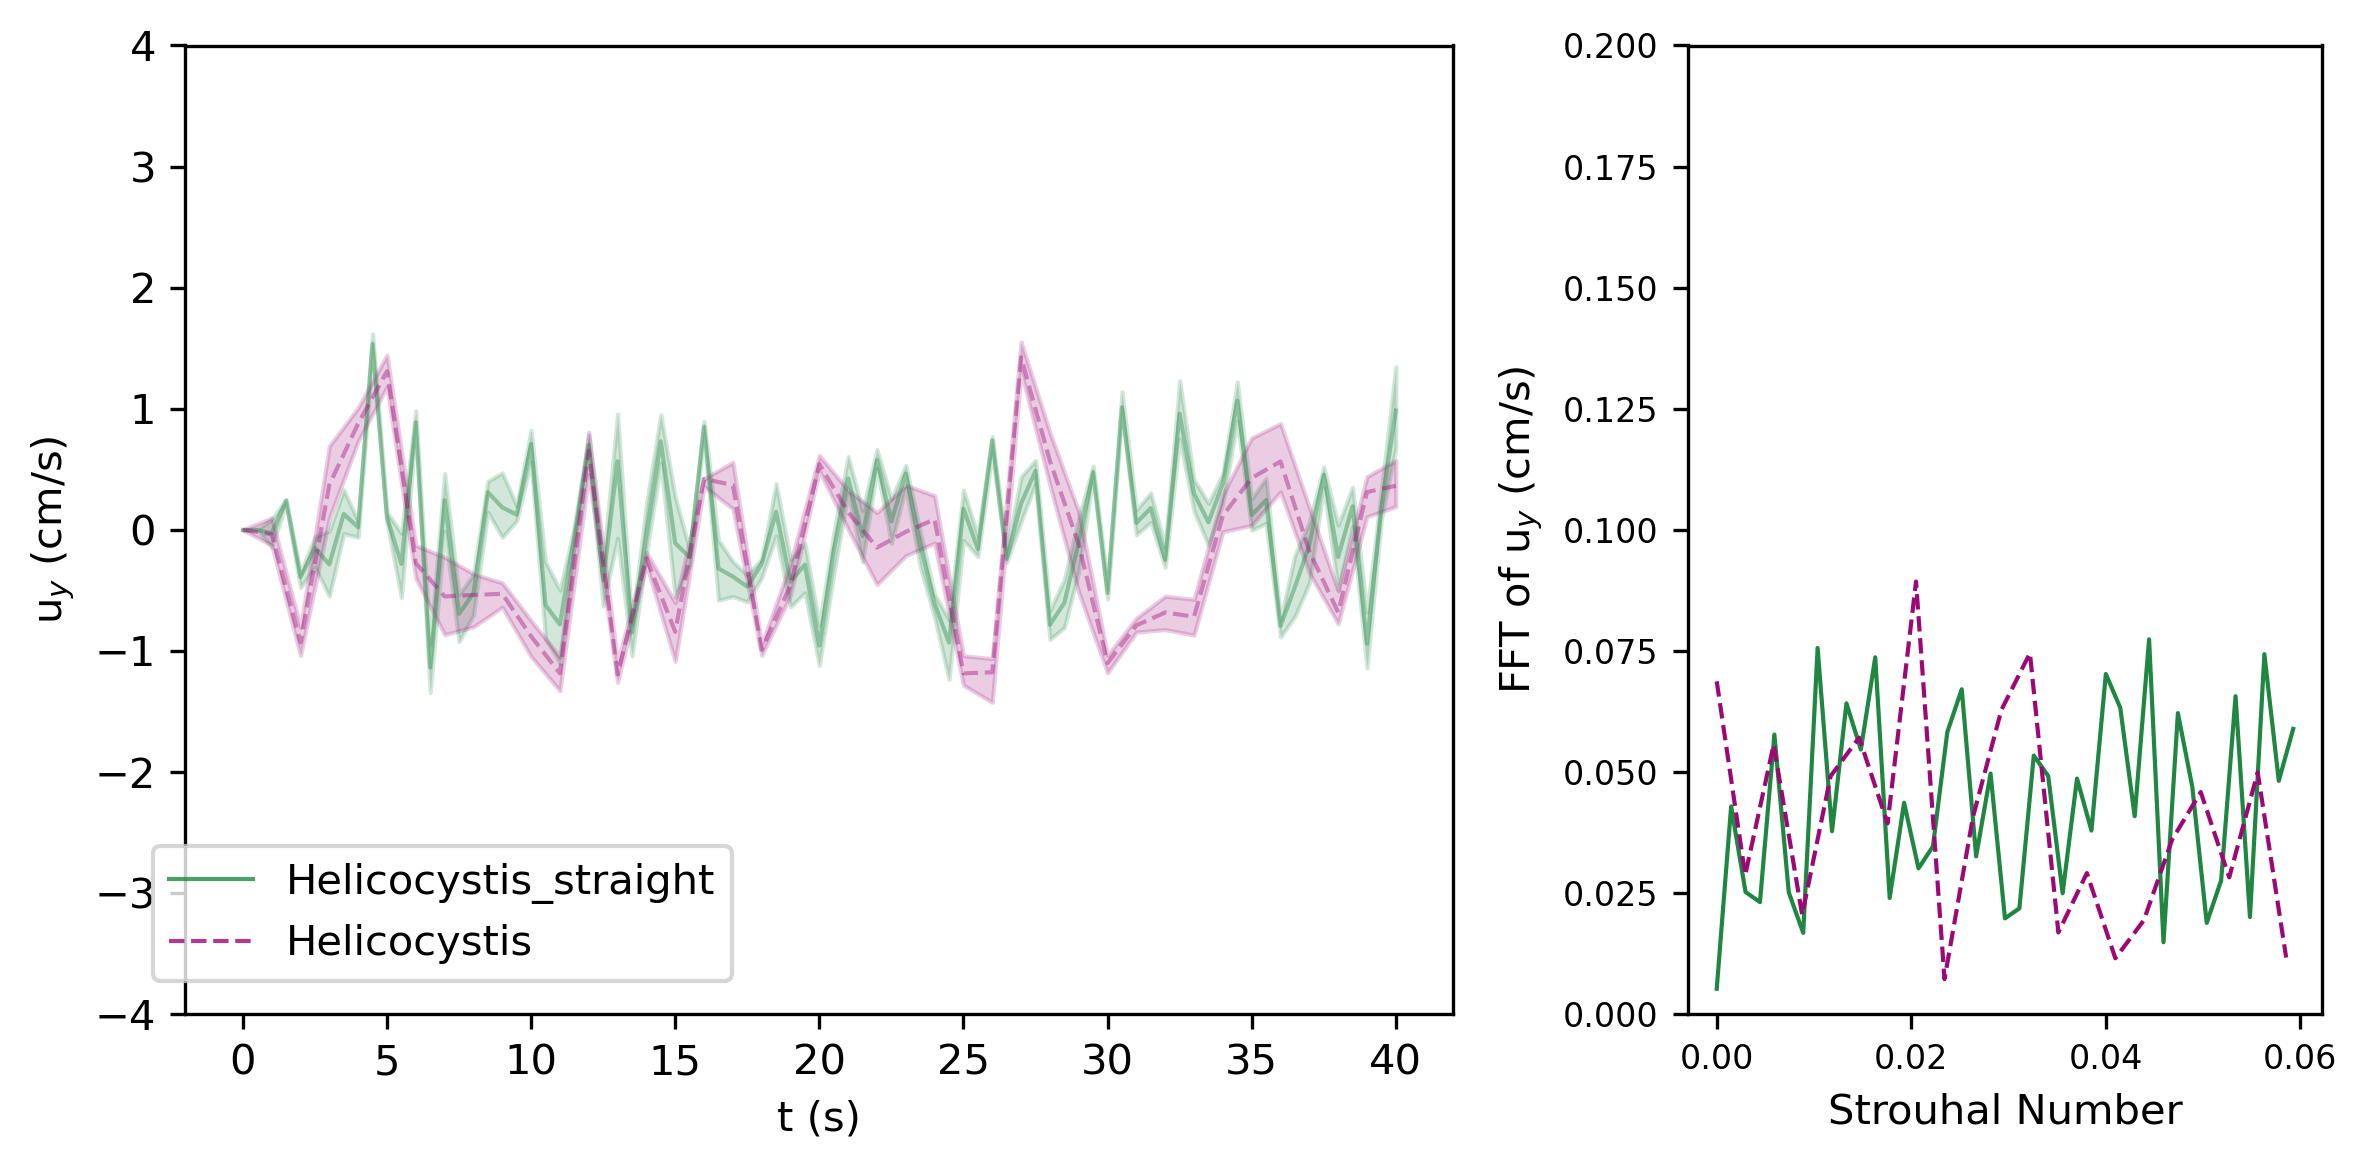

In [7]:
time_series_helico = U_read('helicocystis', 'time_series.csv')
time_series_helico_straight = U_read('helicocystis_straight', 'time_series.csv')
print(time_series_helico.shape[1])
FFT_helico = FFT_read('helicocystis', 'FFT.csv', 0.012)
FFT_helico_straight = FFT_read('helicocystis_straight', 'FFT.csv', 0.012)
#plot('Helicocystis', 'Helicocystis_straight', 1, 0.5, time_series_helico, time_series_helico_straight, FFT_helico, FFT_helico_straight)
plot('Helicocystis_straight', 'Helicocystis', 0.5, 1, time_series_helico_straight, time_series_helico, FFT_helico_straight, FFT_helico)
#plt.savefig('time_series_helicocystis.pdf', dpi=300)

[0.         0.02439024 0.04878049 0.07317073 0.09756098 0.12195122
 0.14634146 0.17073171 0.19512195 0.2195122  0.24390244 0.26829268
 0.29268293 0.31707317 0.34146341 0.36585366 0.3902439  0.41463415
 0.43902439 0.46341463 0.48780488]
[ 7.01584544e+00+0.j          3.38428531e-03-0.19372306j
  4.24475785e-02-0.00337791j -8.78307801e-02-0.09492166j
 -2.82729540e-01-0.0884566j  -2.24185935e-02-0.14653899j
 -1.03534788e-01+0.03463136j  7.48152735e-02-0.09075131j
 -1.49474460e-01-0.16741988j  1.31878218e-01-0.07831687j
 -3.87475305e-01+0.34526463j -1.65388660e-01-0.02560892j
 -8.44145882e-01-0.16381273j -4.23050163e-01+0.40443664j
 -1.07720477e+00-0.00992854j  6.32691806e-01-0.22755777j
  3.31753396e-01-0.221821j   -4.00330556e-01-0.26095598j
 -5.02661960e-01+0.17864248j -4.82192218e-01-0.12208402j
  2.03544401e-01-0.09910873j]
[0.         0.02439024 0.04878049 0.07317073 0.09756098 0.12195122
 0.14634146 0.17073171 0.19512195 0.2195122  0.24390244 0.26829268
 0.29268293 0.31707317 0.34146

/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


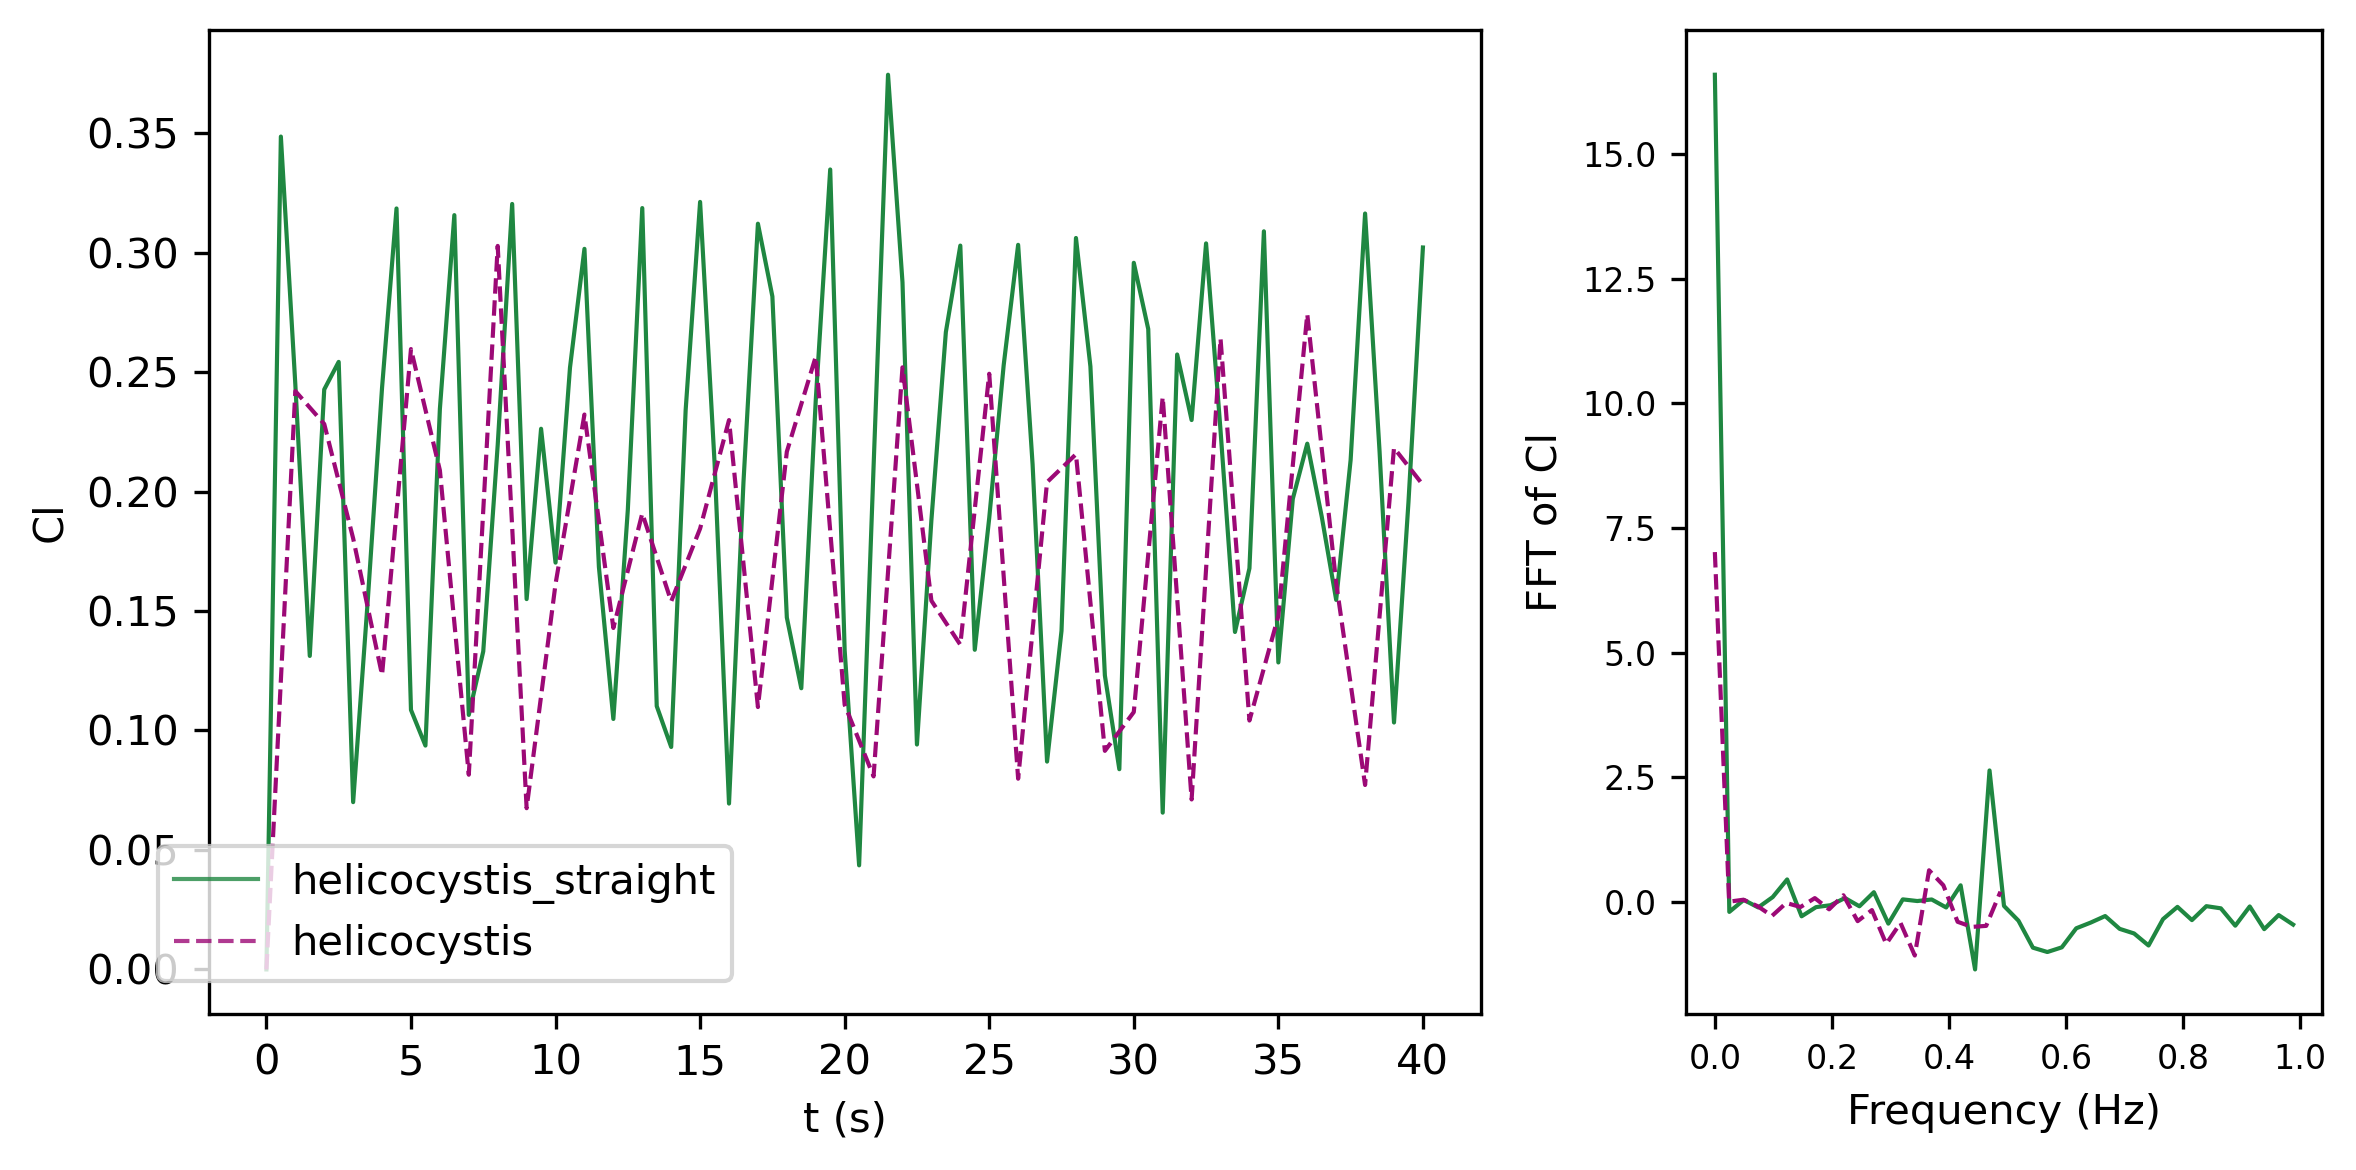

In [3]:
helico = {"taxon1": "helicocystis_straight",
          "taxon2": "helicocystis",
          "writeInt1": 0.5,
          "writeInt2": 1,
          }

helico_data = {"Cl_1": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[0],
                         "Cl_2": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[1],
                         "freq1": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[2],
                         "freq2": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[3],
                         "FFT_Cl_1": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[4],
                         "FFT_Cl_2": read_Cl(helico['taxon1'], helico['taxon2'], helico['writeInt1'], helico['writeInt2'])[5]
                         }

                     
plot_Cl(helico['taxon1'],
        helico['taxon2'], 
        helico['writeInt1'], 
        helico['writeInt2'], 
        helico_data['Cl_1'], 
        helico_data['Cl_2'], 
        helico_data['freq1'], 
        helico_data['freq2'], 
        helico_data['FFT_Cl_1'], 
        helico_data['FFT_Cl_2'])



Power Spectral Density:

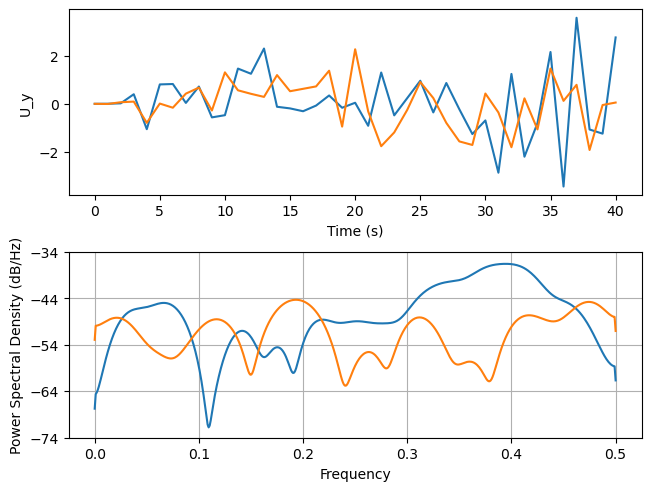

In [12]:
# Stromatocystites
t_stromat = np.arange(0, 40+1, 1)
y_stromat = time_series_stromat[2]
y_kaili = time_series_kaili[2]
fs = 1

fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(t_stromat, y_stromat)
ax0.plot(t_stromat, y_kaili)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('U_y')
ax1.psd(y_stromat,
        NFFT=1024,#len(t_stromat),
        #pad_to=len(t_stromat), 
        Fs=fs,
        sides='onesided'
        )
ax1.psd(y_kaili,
        NFFT=1024,#len(t_stromat),
        #pad_to=len(t_stromat),
        Fs=fs,
        sides='onesided'
        )
plt.show()

(1501,)
(1241,)


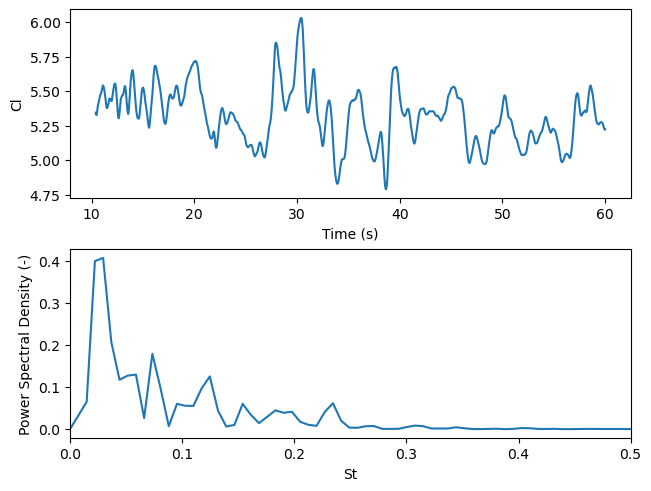

In [6]:
# Stromatocystites high frequency:
dir1 = '../stromatocystites/video/base_case/postProcessing/forces/0/'
#helicocystis_straight/velocity/v0.1/postProcessing/forces/0
filename1 = dir1 + 'forceCoeffs.dat'
# Read the forceCoeffs.dat file and extract Cd values from timestep 50 onwards
with open(filename1, 'r') as file:
    lines = file.readlines()
    if not lines:
        raise ValueError("The file is empty.")
    #data_lines = lines[29:]  # take data from 30s onwards
    Cl_1_list = []
    for line in lines:
        if line.strip() and not line.startswith('#'):
            parts = line.split()
            if len(parts) > 2:
                Cl_1_list.append(float(parts[3]))
    Cl_1 =  np.array(Cl_1_list)
    print(Cl_1.shape)

Cl_1 = Cl_1[260:] # last 4 seconds of dataset
t = np.arange(10.4, 60+0.04, 0.04)
print(t.shape)
fs = 1/0.04

fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(t, Cl_1)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Cl')
#ax1.psd(Cl_1, 
        #pad_to=len(t), 
#        NFFT=1024,#len(t),
#        Fs=fs,
#        sides='onesided'
#        )
f, pxx = welch(Cl_1, fs, nperseg=1024)
L = 0.03
U = 0.1
strouhal = f*L/U
ax1.plot(strouhal, pxx)
ax1.set_xlabel("St")
ax1.set_ylabel("Power Spectral Density (-)")

ax1.set_xlim(0,0.5)
plt.show()

/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


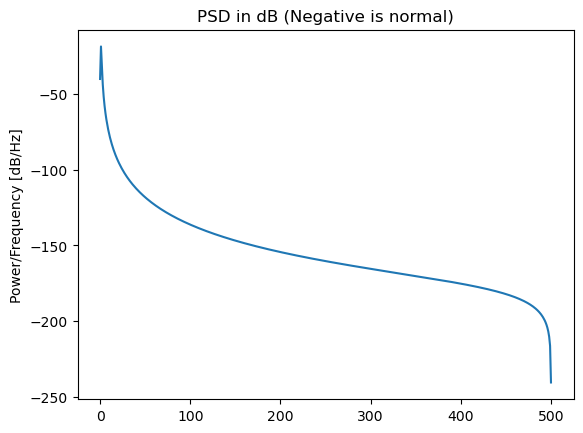

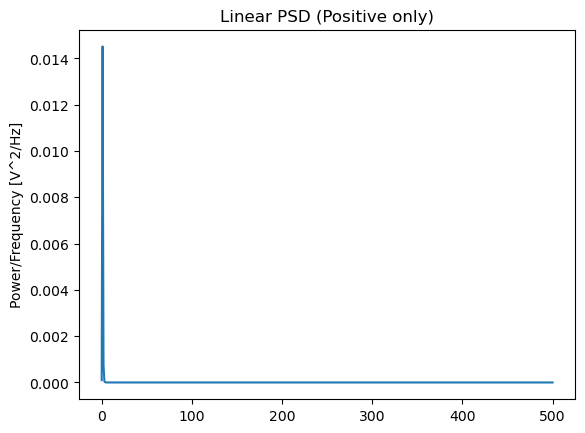

In [23]:
from scipy.signal import welch

# Generate a signal
fs = 1000
t = np.linspace(0, 1, fs)
sig = np.sin(t)

# Compute PSD
f, pxx = welch(sig, fs, nperseg=1024)

# Plotting with Log Scale (Produces negative values)
plt.figure()
plt.plot(f, 10 * np.log10(pxx))
plt.title("PSD in dB (Negative is normal)")
plt.ylabel("Power/Frequency [dB/Hz]")

# Plotting with Linear Scale (All positive)
plt.figure()
plt.plot(f, pxx)
plt.title("Linear PSD (Positive only)")
plt.ylabel("Power/Frequency [V^2/Hz]")
plt.show()

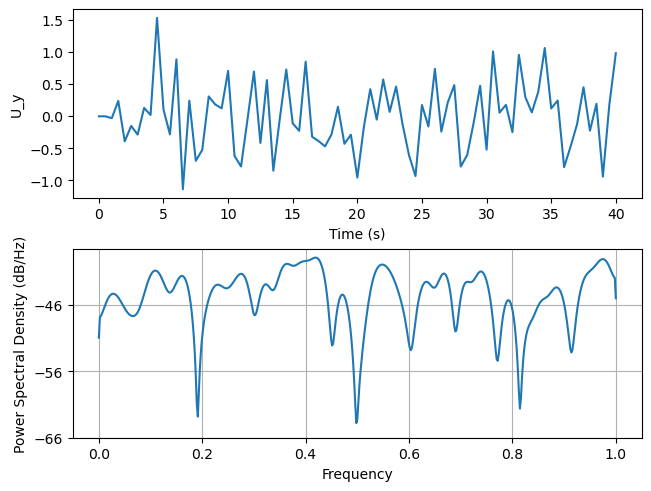

In [ ]:
#Helicocystis straight U_y
t = np.arange(0, 40+0.5, 0.5)
y = time_series_helico_straight[2]
fs = 1/0.5

fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(t, y)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('U_y')
ax1.psd(y, 
        NFFT=1024,#len(t),
        #pad_to=len(t), 
        Fs=fs,
        sides='onesided'
        )
plt.show()


81


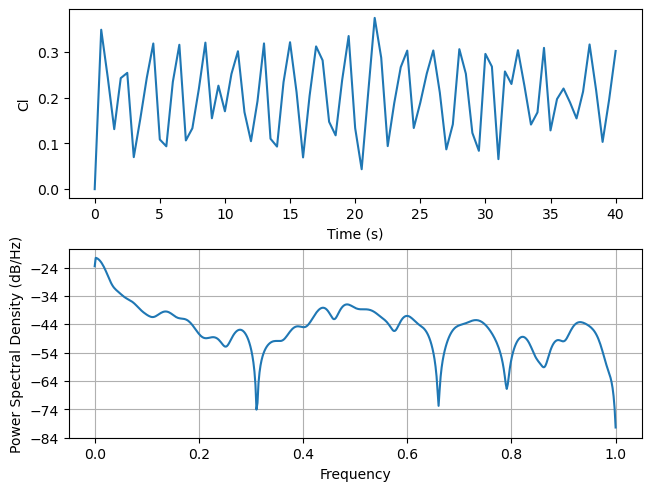

In [10]:
# Helicocystis straight Cl:
t_Cl = np.arange(0, 40+0.5, 0.5)
y_Cl = helico_data["Cl_1"] # Cl is in 4th column of time series data
print(len(y_Cl))
fs = 1/0.5
fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(t_Cl, y_Cl)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Cl')
ax1.psd(y_Cl, 
        NFFT=512, 
        pad_to=1024,
        Fs=fs,
        sides='onesided'
        )
plt.show()

### Gogiids:

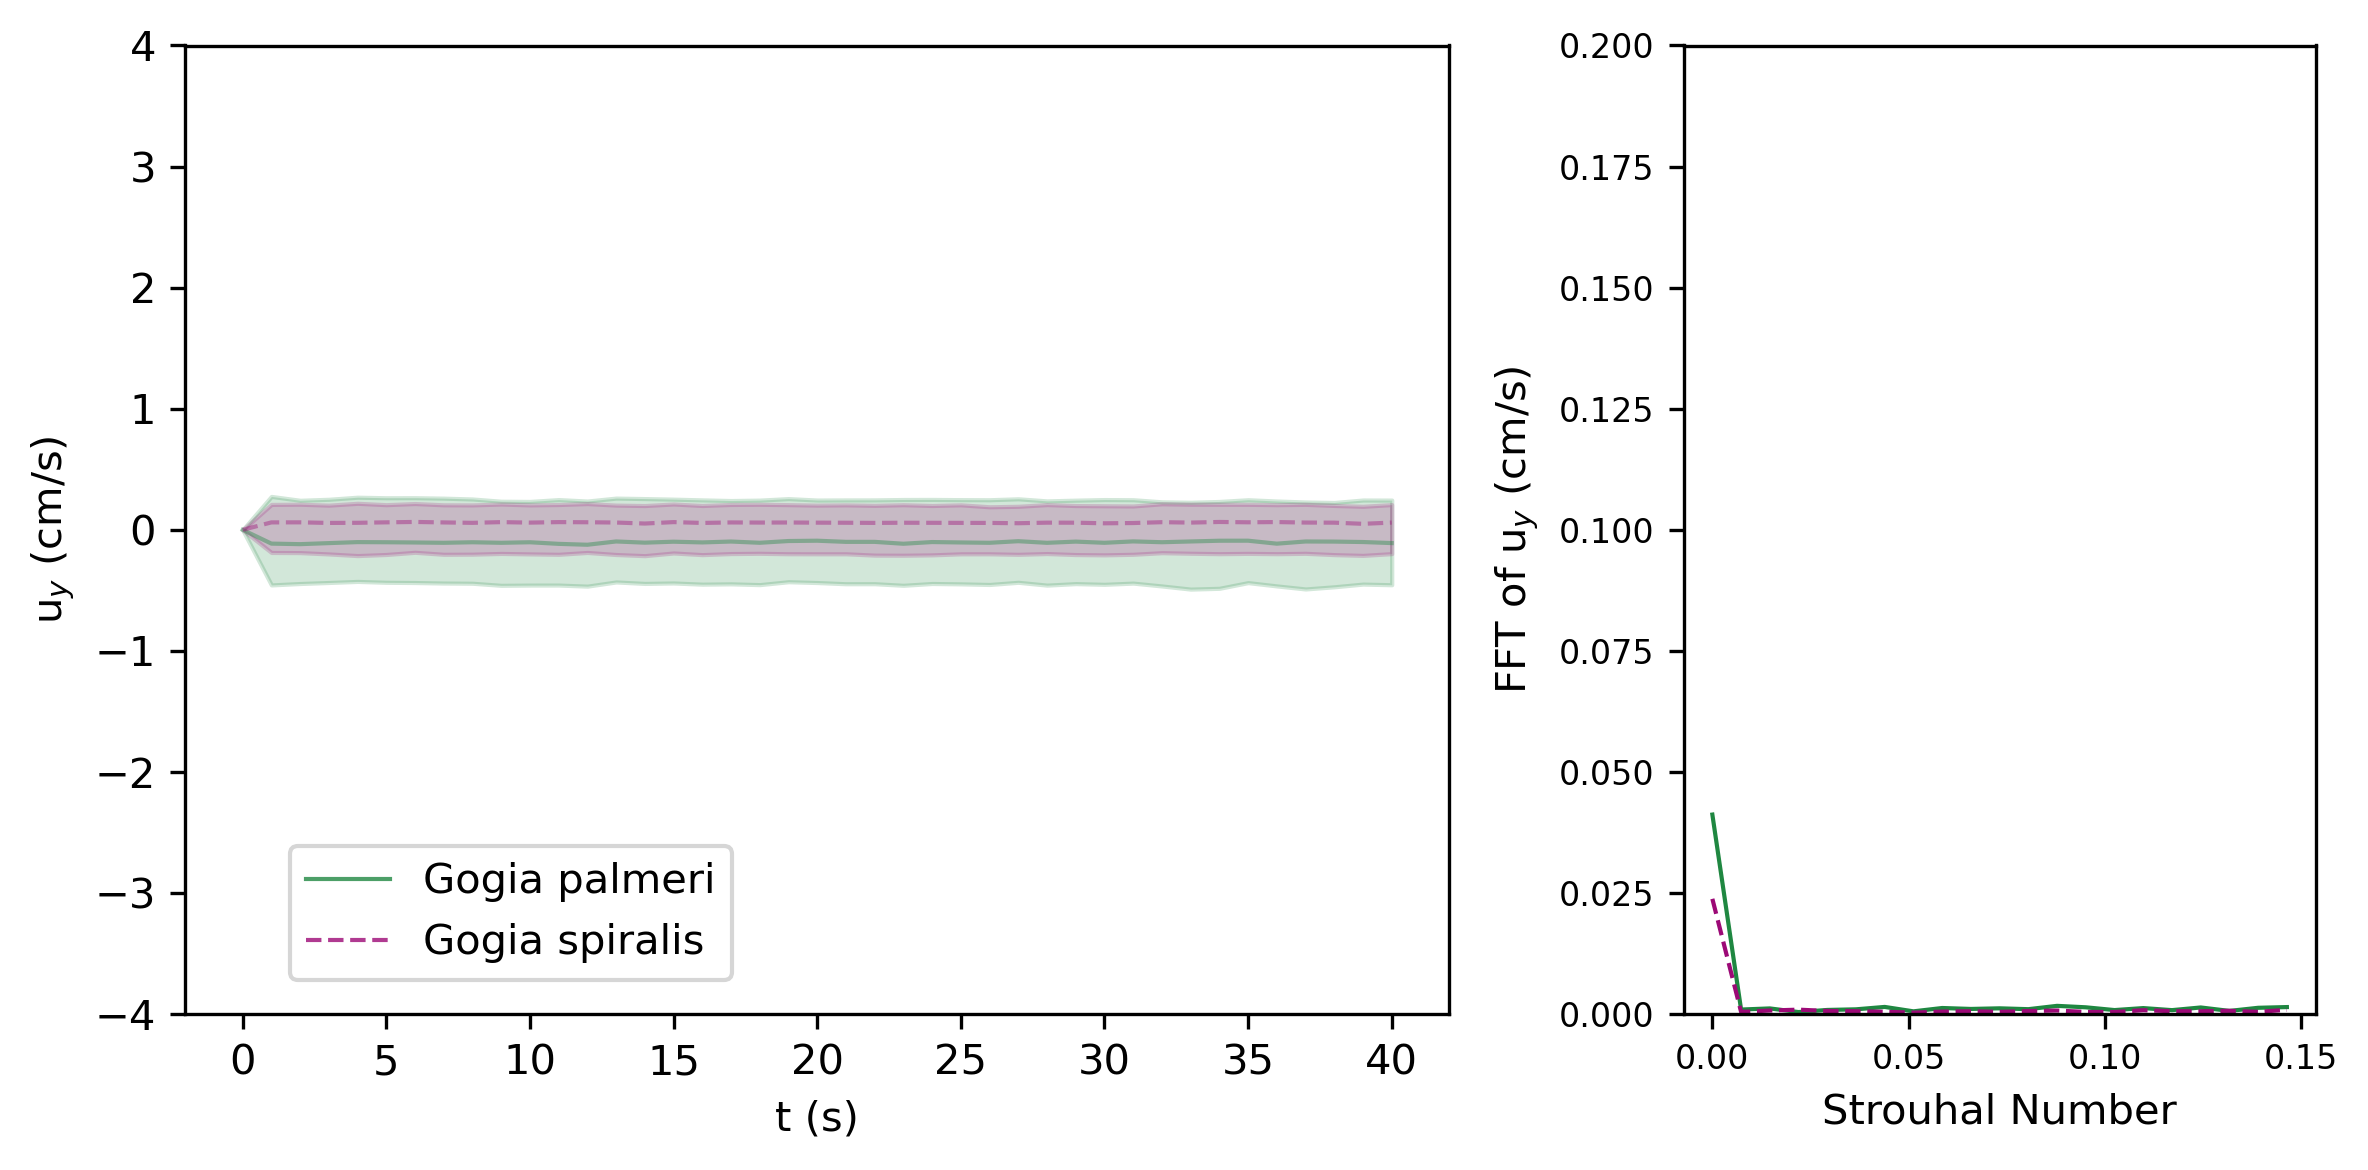

In [58]:
time_series_palmeri = U_read('gogia_palmeri', 'time_series.csv')
time_series_spiralis = U_read('gogia_spiralis', 'time_series.csv')
FFT_palmeri = FFT_read('gogia_palmeri', 'FFT.csv', 0.03)
FFT_spiralis = FFT_read('gogia_spiralis', 'FFT.csv', 0.03)
plot('Gogia palmeri', 'Gogia spiralis', 1, 1, time_series_palmeri, time_series_spiralis, FFT_palmeri, FFT_spiralis)
plt.savefig('time_series_gogiids.pdf', dpi=300)